In [6]:
import pandas as pd
import re
from pathlib import Path
import numpy as np
import os
from sklearn import metrics
from sklearn.metrics import confusion_matrix, precision_recall_curve, precision_score, recall_score, f1_score, roc_auc_score, PrecisionRecallDisplay
from sklearn.metrics import ConfusionMatrixDisplay, auc
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import soundfile as sf
from intervaltree import IntervalTree
from PIL import Image
import io
# from utils.metadata_processing import (reorder_columns_to_default_view, 
                                       # correct_call_times_with_duration,
                                       # non_overlap_df, bg_from_non_overlap_calls)

In [17]:
# Define paths
wav_folder = r'C:\Users\amitg\Documents\Deep_Voice\HF_WAV_Manatee_Samples\Placencia\wavs'
annotations_folder = r'C:\Users\amitg\Documents\Deep_Voice\HF_WAV_Manatee_Samples\Placencia\augmented_annotations2'

# List of inference folders and their labels
folders = [
    (r'C:\Users\amitg\Documents\Deep_Voice\HF_WAV_Manatee_Samples\Placencia\placencia_inference2', 'No finetune'),
    (r'C:\Users\amitg\Documents\Deep_Voice\HF_WAV_Manatee_Samples\Placencia\placencia_inference_mft3_redo', 'finetune 3%'),
    (r'C:\Users\amitg\Documents\Deep_Voice\HF_WAV_Manatee_Samples\Placencia\placencia_inference_mft5_redo', 'finetune 5%'),
    (r'C:\Users\amitg\Documents\Deep_Voice\HF_WAV_Manatee_Samples\Placencia\placencia_inference_mft10_redo', 'finetune 10%'),
    (r'C:\Users\amitg\Documents\Deep_Voice\HF_WAV_Manatee_Samples\Placencia\placencia_inference_mft15_redo', 'finetune 15%'),
]

annotation_dfs = []

def extract_recording_filename_from_annotation(filename):
    return filename.split('adjusted_')[1].split('.Table.1.selections_bb.txt')[0]

def extract_recording_filename_from_prediction(filename):
    basename = os.path.basename(filename)
    # Remove the extension
    filename_wo_ext = os.path.splitext(basename)[0]
    # Split on '-' and get the last part
    parts = filename_wo_ext.split('-')
    last_part = parts[-1]
    # For filenames with extra suffixes like '-thresh05', split again
    recording_filename = last_part.split('-')[0]
    return recording_filename

# Read all annotation files
name_mappings = []
for annotation_file in os.listdir(annotations_folder):
    if annotation_file.endswith('.txt'):
        file_path = os.path.join(annotations_folder, annotation_file)
        df = pd.read_csv(file_path, delimiter='\t')
        recording_filename = extract_recording_filename_from_annotation(annotation_file)
        name_mappings.append([recording_filename, annotation_file])
        df['recording_filename'] = recording_filename
        annotation_dfs.append(df)

# Concatenate all dataframes into a single dataframe for annotations
annotations_df = pd.concat(annotation_dfs, ignore_index=True)
annotations_df = annotations_df[annotations_df['Begin Time (s)'] <= 10800]

# Convert begin_time and end_time to seconds
annotations_df['Begin Time (s)'] = annotations_df['Begin Time (s)'].astype(float)
annotations_df['End Time (s)'] = annotations_df['End Time (s)'].astype(float)

# Compute recording durations and time offsets per recording
recording_durations = {}
time_offsets = {}
time_offset = 0

for recording_filename in annotations_df['recording_filename'].unique():
    recording_annotations = annotations_df[annotations_df['recording_filename'] == recording_filename]
    duration = recording_annotations['End Time (s)'].max()
    recording_durations[recording_filename] = duration
    time_offsets[recording_filename] = time_offset
    time_offset += duration

In [18]:
annotations_df

,Selection,View,Channel,Begin Time (s),End Time (s),Low Freq (Hz),Delta Time (s),Delta Freq (Hz),High Freq (Hz),Inband Power (dB FS),Begin Date Time,SNR,NUM HARM,recording_filename
0,1,Spectrogram 1,1,412.928222,413.186087,11902.439,0.2579,12682.927,24585.366,-93.32,2012/12/10 15:29:52.9282,3.3,2,67670025.201212101523
1,2,Spectrogram 1,1,415.595797,415.688457,3719.600,0.0927,10914.546,14634.146,-93.64,2012/12/10 15:29:55.5958,0.3,2,67670025.201212101523
2,3,Spectrogram 1,1,418.951454,419.321578,9560.976,0.3701,14243.902,23804.878,-92.90,2012/12/10 15:29:58.9515,4.1,3,67670025.201212101523
3,4,Spectrogram 1,1,463.320853,463.487096,1170.732,0.1662,6829.268,8000.000,-94.22,2012/12/10 15:30:43.3209,0.8,2,67670025.201212101523
4,5,Spectrogram 1,1,496.389546,496.454953,7414.634,0.0654,15798.481,23213.115,-94.09,2012/12/10 15:31:16.3895,0.0,1,67670025.201212101523
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
619,669,Spectrogram 1,1,9785.462775,9785.778815,3594.714,0.3160,16704.846,20299.559,NaN,2012/12/11 6:05:46.4873,NaN,4,67670025.201212221503
620,670,Spectrogram 1,1,9787.890885,9788.230049,3806.167,0.3392,14167.401,17973.568,NaN,2012/12/11 6:05:48.9154,NaN,3,67670025.201212221503
621,671,Spectrogram 1,1,9791.744891,9792.037806,6555.066,0.2929,24105.727,30660.793,NaN,2012/12/11 6:05:52.7694,NaN,4,67670025.201212221503
622,672,Spectrogram 1,1,9799.420572,9799.721195,5920.705,0.3006,13744.493,19665.198,NaN,2012/12/11 6:06:00.4451,NaN,2,67670025.201212221503


In [19]:
# Function to calculate calls per time unit with continuous time for annotations
def calculate_calls_per_time_unit_annotations(annotations_df, time_offsets):
    adjusted_annotations = []
    for recording_filename in annotations_df['recording_filename'].unique():
        recording_annotations = annotations_df[annotations_df['recording_filename'] == recording_filename].copy()
        time_offset = time_offsets[recording_filename]
        recording_annotations['adjusted_begin_time'] = recording_annotations['Begin Time (s)'] + time_offset
        recording_annotations['adjusted_end_time'] = recording_annotations['End Time (s)'] + time_offset
        adjusted_annotations.append(recording_annotations)
    adjusted_annotations_df = pd.concat(adjusted_annotations, ignore_index=True)
    adjusted_annotations_df['datetime'] = pd.to_datetime(adjusted_annotations_df['adjusted_begin_time'], unit='s')
    adjusted_annotations_df['hour'] = (adjusted_annotations_df['adjusted_begin_time'] // 3600).astype(int)
    calls_per_hour = adjusted_annotations_df.groupby('hour').size().reset_index(name='calls_per_hour')
    adjusted_annotations_df['minute'] = (adjusted_annotations_df['adjusted_begin_time'] // 60).astype(int)
    calls_per_minute = adjusted_annotations_df.groupby('minute').size().reset_index(name='calls_per_minute')
    return calls_per_hour, calls_per_minute

# Calculate calls per hour and per minute for annotations
calls_per_hour_annotations, calls_per_minute_annotations = calculate_calls_per_time_unit_annotations(annotations_df, time_offsets)

# Dictionaries to store calls per hour and per minute for each folder
calls_per_hour_dict = {}
calls_per_minute_dict = {}

# Process each folder
for folder_path, label in folders:
    folder_name = os.path.basename(folder_path)
    prediction_dfs = []
    # Read all prediction files
    for prediction_file in os.listdir(folder_path):
        if prediction_file.endswith('.csv') and prediction_file.startswith('Inference_results'):
            file_path = os.path.join(folder_path, prediction_file)
            df = pd.read_csv(file_path)
            # Reset the index to ensure it's numeric
            df.reset_index(drop=True, inplace=True)
            recording_filename = extract_recording_filename_from_prediction(prediction_file)
            if recording_filename not in time_offsets:
                print(f"Recording filename {recording_filename} not in annotations, skipping.")
                continue
            df['recording_filename'] = recording_filename
            # Add a column for time_segment in the predictions dataframe
            df['time_segment'] = df.index * 0.2
            prediction_dfs.append(df)
    # Concatenate all dataframes into a single dataframe for predictions
    if len(prediction_dfs) == 0:
        print(f"No valid prediction files found in folder {folder_path}")
        continue
    predictions_df = pd.concat(prediction_dfs, ignore_index=True)

    # Function to calculate calls per time unit with continuous time
    def calculate_calls_per_time_unit_continuous(predictions_df, threshold=0.5, time_offsets=None):
        predictions_df['predicted_label'] = (predictions_df['1'] >= threshold).astype(int)
        adjusted_predictions = []
        for recording_filename in predictions_df['recording_filename'].unique():
            recording_predictions = predictions_df[predictions_df['recording_filename'] == recording_filename].copy()
            time_offset = time_offsets[recording_filename]
            recording_predictions['adjusted_time_segment'] = recording_predictions['time_segment'] + time_offset
            adjusted_predictions.append(recording_predictions)
        adjusted_predictions_df = pd.concat(adjusted_predictions, ignore_index=True)
        adjusted_predictions_df['datetime'] = pd.to_datetime(adjusted_predictions_df['adjusted_time_segment'], unit='s')
        adjusted_predictions_df['hour'] = (adjusted_predictions_df['adjusted_time_segment'] // 3600).astype(int)
        calls_per_hour = adjusted_predictions_df[adjusted_predictions_df['predicted_label'] == 1].groupby('hour').size().reset_index(name='calls_per_hour')
        adjusted_predictions_df['minute'] = (adjusted_predictions_df['adjusted_time_segment'] // 60).astype(int)
        calls_per_minute = adjusted_predictions_df[adjusted_predictions_df['predicted_label'] == 1].groupby('minute').size().reset_index(name='calls_per_minute')
        return calls_per_hour, calls_per_minute

    # Calculate the number of calls per hour and per minute with continuous time
    calls_per_hour, calls_per_minute = calculate_calls_per_time_unit_continuous(predictions_df, threshold=0.5, time_offsets=time_offsets)
    # Store the calls per hour and per minute
    calls_per_hour_dict[label] = calls_per_hour
    calls_per_minute_dict[label] = calls_per_minute

for label, df_model in calls_per_hour_dict.items():
    # Merge on 'hour'. Choose how='inner' (only matching hours) or how='outer' and fill missing with 0.
    df_merged = pd.merge(
        calls_per_hour_annotations, 
        df_model, 
        on='hour', 
        suffixes=('_gt', '_pred'),  # ground truth, prediction
        how='inner'  # or 'outer'
    )
    
    # (Optional) If you do outer merge, fill NaN with 0 for calls:
    # df_merged['calls_per_hour_gt']   = df_merged['calls_per_hour_gt'].fillna(0)
    # df_merged['calls_per_hour_pred'] = df_merged['calls_per_hour_pred'].fillna(0)

    # Extract the two numeric arrays
    gt = df_merged['calls_per_hour_gt'].values
    pred = df_merged['calls_per_hour_pred'].values
    
    # Compute Pearson correlation
    pearson_corr, pearson_p = pearsonr(gt, pred)
    
    # Compute Spearman correlation (if desired)
    spearman_corr, spearman_p = spearmanr(gt, pred)
    
    # Optionally compute other metrics
    # 
    mse = mean_squared_error(gt, pred)
    r2 = r2_score(gt, pred)
    
    # Print out the results
    print(f"Model: {label}")
    print(f"  Pearson correlation = {pearson_corr:.3f} (p-value={pearson_p:.3e})")
    print(f"  Spearman correlation = {spearman_corr:.3f} (p-value={spearman_p:.3e})")
    print(f"  MSE = {mse}, R^2 = {r2}")
    print("-----------")

Model: No finetune
  Pearson correlation = 0.408 (p-value=1.881e-01)
  Spearman correlation = 0.476 (p-value=1.176e-01)
  MSE = 2028.0833333333333, R^2 = -0.7300877354075461
-----------
Model: finetune 3%
  Pearson correlation = 0.366 (p-value=1.797e-01)
  Spearman correlation = 0.663 (p-value=7.049e-03)
  MSE = 26464.933333333334, R^2 = -20.134074405332314
-----------
Model: finetune 5%
  Pearson correlation = 0.465 (p-value=8.048e-02)
  Spearman correlation = 0.781 (p-value=5.868e-04)
  MSE = 6942.933333333333, R^2 = -4.544411082007709
-----------
Model: finetune 10%
  Pearson correlation = 0.923 (p-value=9.290e-07)
  Spearman correlation = 0.911 (p-value=2.422e-06)
  MSE = 1502.4666666666667, R^2 = -0.19982325006920942
-----------
Model: finetune 15%
  Pearson correlation = 0.929 (p-value=5.855e-07)
  Spearman correlation = 0.908 (p-value=2.899e-06)
  MSE = 3199.133333333333, R^2 = -1.5547285930279608
-----------


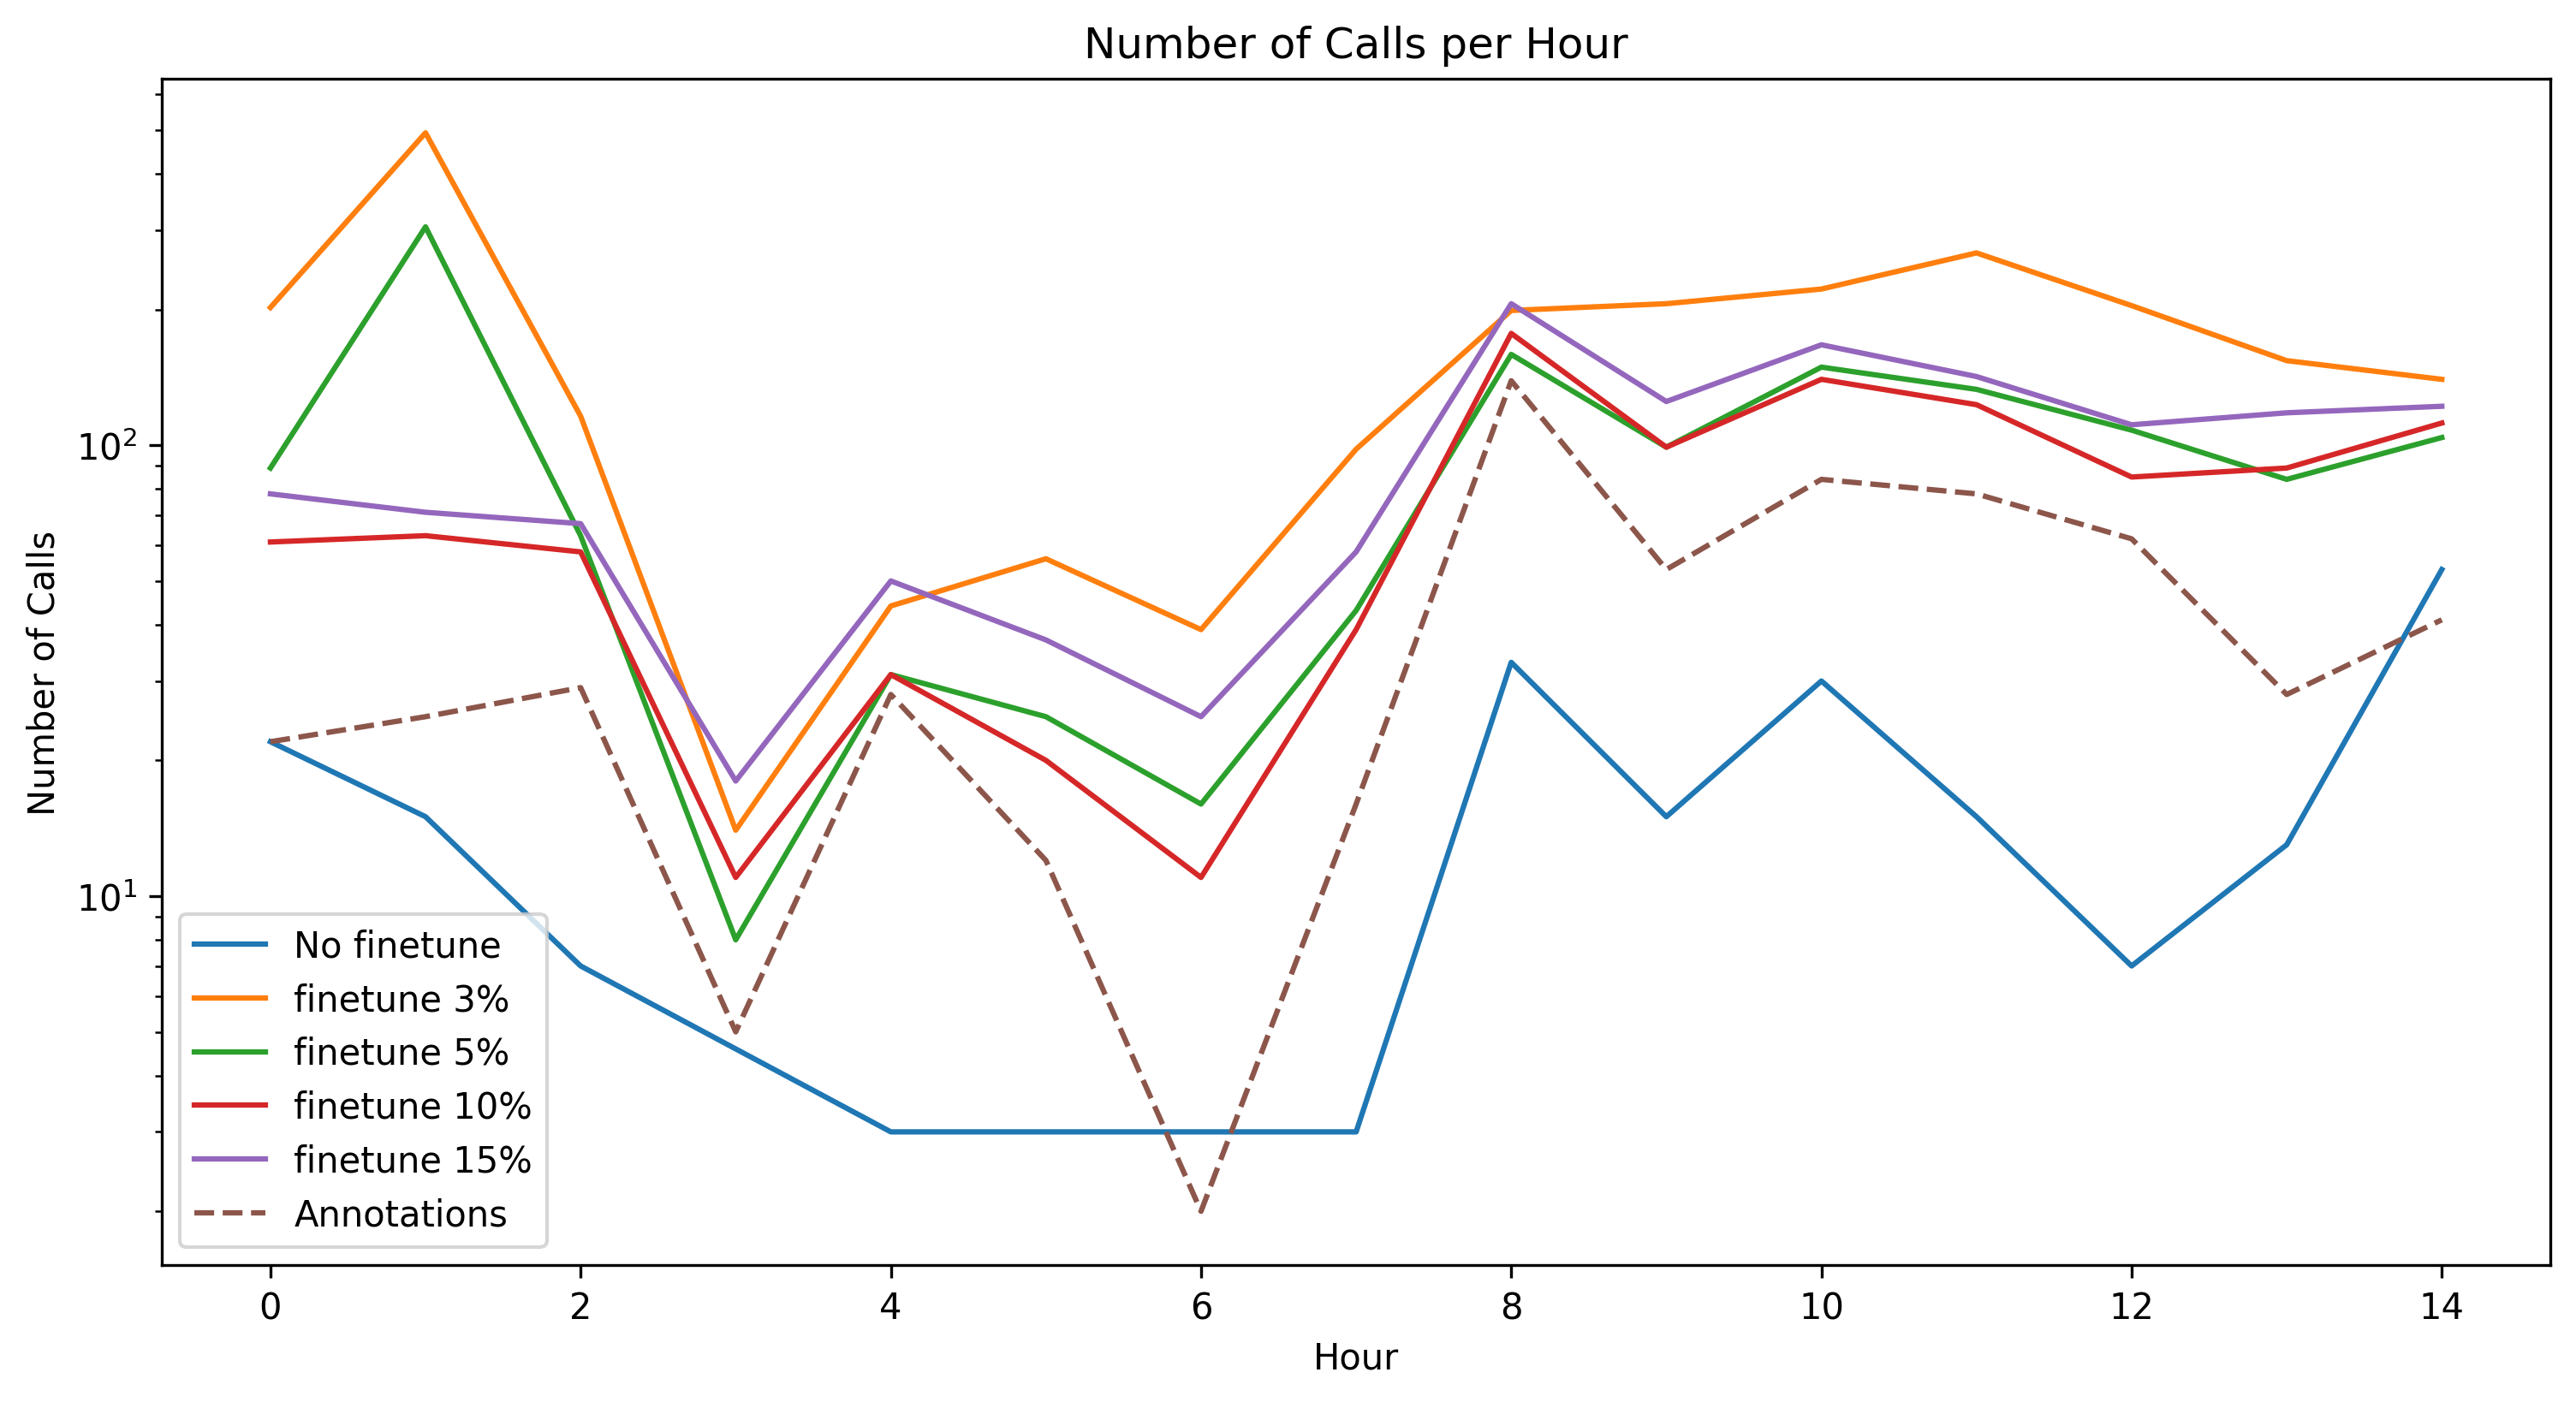

C:\Users\amitg\AppData\Local\Temp\ipykernel_1400\2948594077.py:28: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  plt.ylim(top=100,bottom=0)


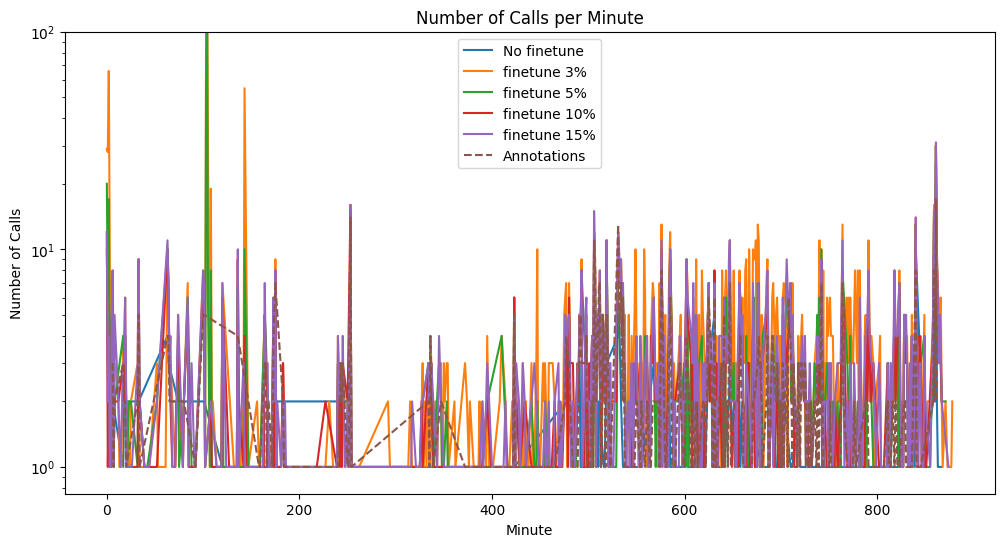

In [20]:
# Plot the number of calls per hour
fig = plt.figure(figsize=(12, 6), dpi=300)
for label, calls_per_hour in calls_per_hour_dict.items():
    plt.plot(calls_per_hour['hour'], calls_per_hour['calls_per_hour'], label=label)
plt.plot(calls_per_hour_annotations['hour'], calls_per_hour_annotations['calls_per_hour'], label='Annotations', linestyle='--')
plt.xlabel('Hour')
plt.ylabel('Number of Calls')
plt.yscale('log')
plt.title('Number of Calls per Hour')
plt.legend()
plt.show()
output_name = "call_per_hour_microfinetune.tiff"
png1 = io.BytesIO()
fig.savefig(png1, format='png')
png2 = Image.open(png1)
png2.save(output_name)
png1.close()
# Plot the number of calls per minute
plt.figure(figsize=(12, 6))
for label, calls_per_minute in calls_per_minute_dict.items():
    plt.plot(calls_per_minute['minute'], calls_per_minute['calls_per_minute'], label=label)
plt.plot(calls_per_minute_annotations['minute'], calls_per_minute_annotations['calls_per_minute'], label='Annotations', linestyle='--')
plt.xlabel('Minute')
plt.ylabel('Number of Calls')
plt.yscale('log')
plt.title('Number of Calls per Minute')
plt.legend()
plt.ylim(top=100,bottom=0)
plt.show()

,channel,0,1,recording_filename,time_segment
269878,1,0.996514,0.003486,67670025.201212221503,10795.0
269879,1,0.998650,0.001350,67670025.201212221503,10795.2
269880,1,0.996501,0.003499,67670025.201212221503,10795.4
269881,1,0.996142,0.003858,67670025.201212221503,10795.6
269882,1,0.995280,0.004720,67670025.201212221503,10795.8
269883,1,0.995701,0.004299,67670025.201212221503,10796.0
269884,1,0.997076,0.002925,67670025.201212221503,10796.2
269885,1,0.993894,0.006106,67670025.201212221503,10796.4
269886,1,0.998081,0.001919,67670025.201212221503,10796.6
269887,1,0.992269,0.007731,67670025.201212221503,10796.8


Predicted probability distribution:
count    269898.000000
mean          0.004195
std           0.026480
min           0.000217
25%           0.002220
50%           0.002900
75%           0.003836
max           1.000000
Name: 1, dtype: float64



Metrics at threshold 0.5:
Call Precision: 0.4494
Call Recall: 0.2917
Call F1 Score: 0.3537
Background Precision: 0.9984
Background Recall: 0.9992
Background F1 Score: 0.9988
Confusion Matrix:
[[269051    223]
 [   442    182]]

Metrics at threshold 0.01:
Call Precision: 0.1495
Call Recall: 0.6939
Call F1 Score: 0.2460
Background Precision: 0.9993
Background Recall: 0.9909
Background F1 Score: 0.9951
Confusion Matrix:
[[266811   2463]
 [   191    433]]

Best Threshold: 0.0287



Metrics at threshold 0.5:
Call Precision: 0.8426
Call Recall: 0.2917
Call F1 Score: 0.4333
Background Precision: 0.9984
Background Recall: 0.9999
Background F1 Score: 0.9991
Confusion Matrix:
[[268669     34]
 [   442    182]]
AUC-PR: 0.4904

Metrics at threshold 0.01:
Call Precision: 0.1630
Call Recall: 0.6939
Call F1 Score: 0.2640
Background Precision: 0.9993
Background Recall: 0.9917
Background F1 Score: 0.9955
Confusion Matrix:
[[266480   2223]
 [   191    433]]
AUC-PR: 0.4904

Best Threshold: 0.0570


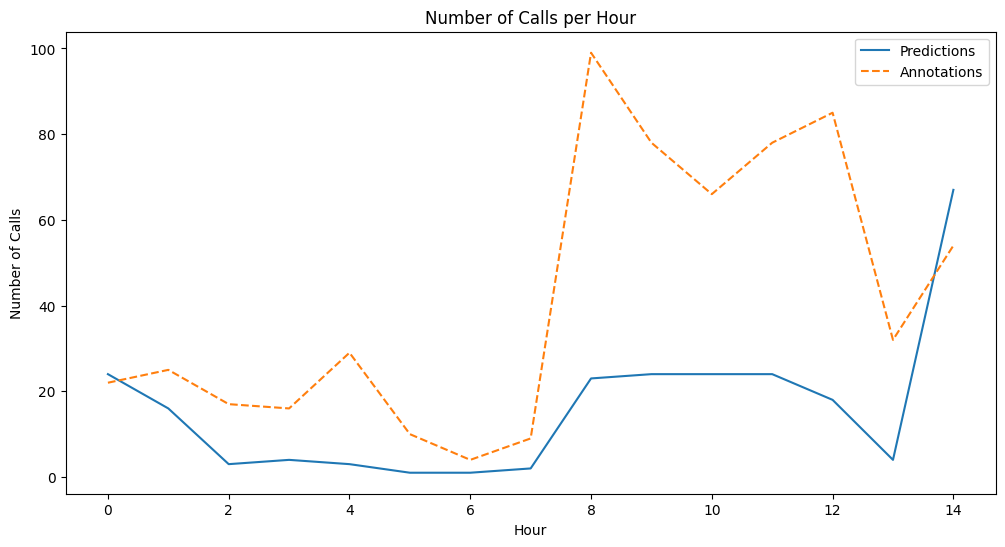

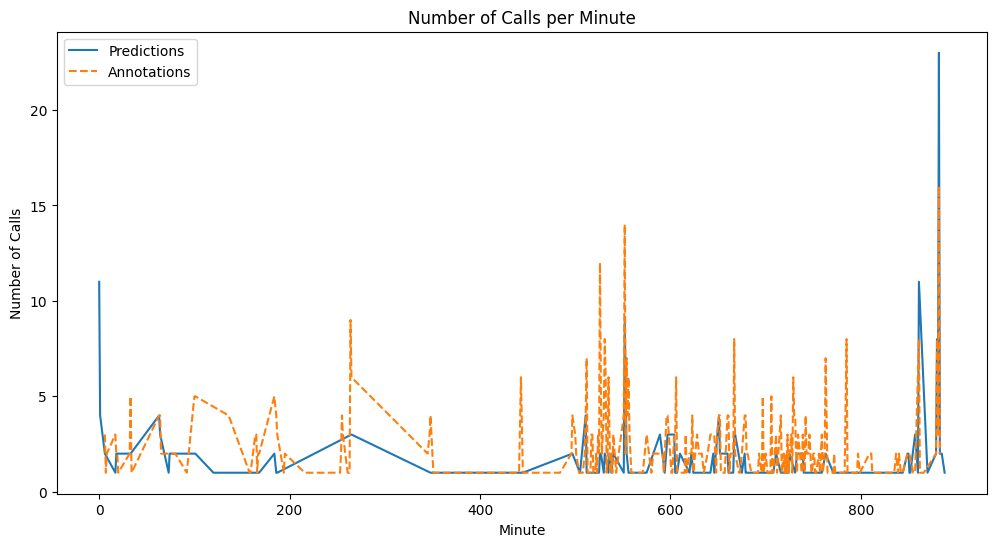